In [2]:
from google.colab import drive

drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

Mounted at /content/drive


In [3]:
RESULTS_DIR = Path(
    "/content/drive/MyDrive/"
    "bachelor_thesis_data/results/tables"
)

FIGURE_DIR = Path(
    "/content/drive/MyDrive/"
    "bachelor_thesis_data/results/figures"
)

PREDICTION_FILES = {
    "Baseline": (
        RESULTS_DIR /
        "baseline_seed42_test_predictions.csv"
    ),

    "Traditional augmentation - doubled": (
        RESULTS_DIR /
        "traditional_aug_seed42_double_test_predictions.csv"
    ),

    "Traditional augmentation - balanced": (
        RESULTS_DIR /
        "traditional_aug_seed42_test_predictions.csv"
    ),

    "Class weighting": (
        RESULTS_DIR /
        "class_weighting_seed42_test_predictions.csv"
    ),

    "GAN augmentation - doubled": (
        RESULTS_DIR /
        "gan_augmentation_double_500kimg_test_predictions.csv"
    ),

    "GAN augmentation - balanced": (
        RESULTS_DIR /
        "gan_augmentation_5050_500kimg_test_predictions.csv"
    ),

    "Diffusion augmentation - doubled": (
        RESULTS_DIR /
        "diffusion_augmentation_double_test_predictions.csv"
    ),

    "Diffusion augmentation - balanced": (
        RESULTS_DIR /
        "diffusion_augmentation_balanced_test_predictions.csv"
    )
}

COLORS = {
    "Baseline": "#000000",
    "Traditional augmentation - doubled": "#1F77B4",
    "Traditional augmentation - balanced": "#17BECF",
    "Class weighting": "#9467BD",
    "GAN augmentation - doubled": "#FF7F0E",
    "GAN augmentation - balanced": "#D62728",
    "Diffusion augmentation - doubled": "#2CA02C",
    "Diffusion augmentation - balanced": "#8C564B"
}

LINE_STYLES = {
    "Baseline": "-",
    "Traditional augmentation - doubled": "-",
    "Traditional augmentation - balanced": "--",
    "Class weighting": "-",
    "GAN augmentation - doubled": "-",
    "GAN augmentation - balanced": "--",
    "Diffusion augmentation - doubled": "-",
    "Diffusion augmentation - balanced": "--"
}

EXPECTED_ROC_AUC = {
    "Baseline": 0.8772106398274622,
    "Traditional augmentation - doubled": 0.8961013106232373,
    "Traditional augmentation - balanced": 0.8986451363158768,
    "Class weighting": 0.8927427233681728,
    "GAN augmentation - doubled": 0.8951390809047172,
    "GAN augmentation - balanced": 0.8928791314125606,
    "Diffusion augmentation - doubled": 0.8931998746520673,
    "Diffusion augmentation - balanced": 0.900027650279268
}

In [4]:
predictions = {}
reference_labels = None

for experiment_name, prediction_path in PREDICTION_FILES.items():

    if not prediction_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file for {experiment_name}:\n"
            f"{prediction_path}"
        )

    prediction_df = pd.read_csv(prediction_path)

    required_columns = {
        "y_true",
        "y_probability",
        "y_pred_0_5"
    }

    if not required_columns.issubset(prediction_df.columns):
        raise ValueError(
            f"{experiment_name} does not contain all required columns."
        )

    y_true = (
        prediction_df["y_true"]
        .to_numpy()
        .reshape(-1)
        .astype(int)
    )

    y_probability = (
        prediction_df["y_probability"]
        .to_numpy()
        .reshape(-1)
        .astype(float)
    )

    y_pred_0_5 = (
        prediction_df["y_pred_0_5"]
        .to_numpy()
        .reshape(-1)
        .astype(int)
    )

    if len(y_true) != 1774:
        raise ValueError(
            f"{experiment_name} contains {len(y_true)} predictions "
            "instead of 1,774."
        )

    if y_true.sum() != 169:
        raise ValueError(
            f"{experiment_name} does not contain 169 melanoma labels."
        )

    if not np.all(np.isfinite(y_probability)):
        raise ValueError(
            f"{experiment_name} contains invalid probabilities."
        )

    if np.any(y_probability < 0) or np.any(y_probability > 1):
        raise ValueError(
            f"{experiment_name} contains probabilities outside [0,1]."
        )

    calculated_predictions = (
        y_probability >= 0.5
    ).astype(int)

    if not np.array_equal(
        y_pred_0_5,
        calculated_predictions
    ):
        raise ValueError(
            f"{experiment_name} contains incorrect threshold predictions."
        )

    if reference_labels is None:
        reference_labels = y_true.copy()

    elif not np.array_equal(
        reference_labels,
        y_true
    ):
        raise ValueError(
            f"The test-label order differs for {experiment_name}."
        )

    calculated_auc = roc_auc_score(
        y_true,
        y_probability
    )

    expected_auc = EXPECTED_ROC_AUC[experiment_name]

    if not np.isclose(
        calculated_auc,
        expected_auc,
        atol=1e-10
    ):
        raise ValueError(
            f"ROC-AUC mismatch for {experiment_name}.\n"
            f"Calculated: {calculated_auc:.10f}\n"
            f"Expected: {expected_auc:.10f}"
        )

    predictions[experiment_name] = {
        "y_true": y_true,
        "y_probability": y_probability,
        "y_pred_0_5": y_pred_0_5
    }

print("All prediction files loaded successfully.")
print(f"Experiments: {len(predictions)}")
print(f"Test images: {len(reference_labels)}")
print(f"Melanoma images: {reference_labels.sum()}")
print(
    "Non-melanoma images:",
    (reference_labels == 0).sum()
)

All prediction files loaded successfully.
Experiments: 8
Test images: 1774
Melanoma images: 169
Non-melanoma images: 1605


In [5]:
curve_summary = []

for experiment_name, prediction_data in predictions.items():

    y_true = prediction_data["y_true"]
    y_probability = prediction_data["y_probability"]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_true,
        y_probability
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_probability
    )

    average_precision = average_precision_score(
        y_true,
        y_probability
    )

    predictions[experiment_name].update({
        "false_positive_rate": false_positive_rate,
        "true_positive_rate": true_positive_rate,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "average_precision": average_precision
    })

    curve_summary.append({
        "Experiment": experiment_name,
        "ROC-AUC": roc_auc,
        "Average precision": average_precision
    })

curve_summary_df = pd.DataFrame(curve_summary)

curve_summary_df = curve_summary_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    curve_summary_df.style.format({
        "ROC-AUC": "{:.4f}",
        "Average precision": "{:.4f}"
    })
)

curve_summary_df.to_csv(
    RESULTS_DIR / "roc_pr_curve_metrics_summary.csv",
    index=False
)

,Experiment,ROC-AUC,Average precision
0,Diffusion augmentation - balanced,0.9000,0.5993
1,Traditional augmentation - balanced,0.8986,0.5757
2,Traditional augmentation - doubled,0.8961,0.5954
3,GAN augmentation - doubled,0.8951,0.6015
4,Diffusion augmentation - doubled,0.8932,0.6376
5,GAN augmentation - balanced,0.8929,0.5784
6,Class weighting,0.8927,0.6040
7,Baseline,0.8772,0.5893


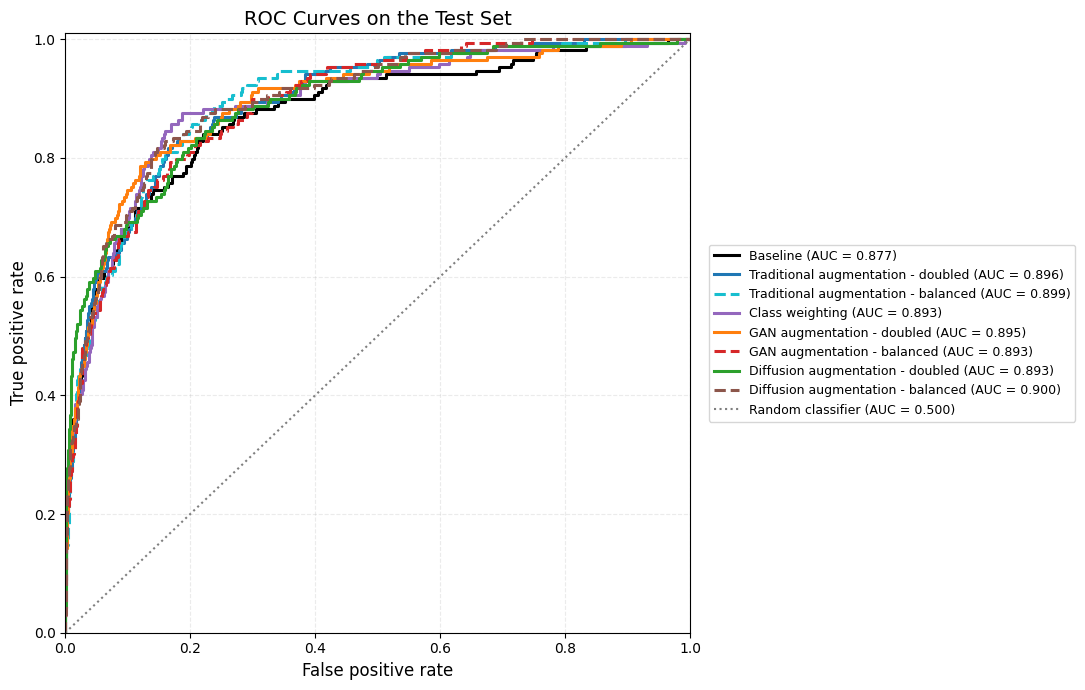

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/roc_curves_all_experiments.png
/content/drive/MyDrive/bachelor_thesis_data/results/figures/roc_curves_all_experiments.pdf


In [6]:
plt.figure(figsize=(11, 7))

for experiment_name, prediction_data in predictions.items():

    plt.plot(
        prediction_data["false_positive_rate"],
        prediction_data["true_positive_rate"],
        color=COLORS[experiment_name],
        linestyle=LINE_STYLES[experiment_name],
        linewidth=2.2,
        label=(
            f"{experiment_name} "
            f"(AUC = {prediction_data['roc_auc']:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    color="#7F7F7F",
    linestyle=":",
    linewidth=1.5,
    label="Random classifier (AUC = 0.500)"
)

plt.xlabel(
    "False positive rate",
    fontsize=12
)

plt.ylabel(
    "True positive rate",
    fontsize=12
)

plt.title(
    "ROC Curves on the Test Set",
    fontsize=14
)

plt.xlim(0, 1)
plt.ylim(0, 1.01)

plt.grid(
    alpha=0.25,
    linestyle="--"
)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()

roc_png_path = (
    FIGURE_DIR /
    "roc_curves_all_experiments.png"
)

roc_pdf_path = (
    FIGURE_DIR /
    "roc_curves_all_experiments.pdf"
)

plt.savefig(
    roc_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    roc_pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(roc_png_path)
print(roc_pdf_path)

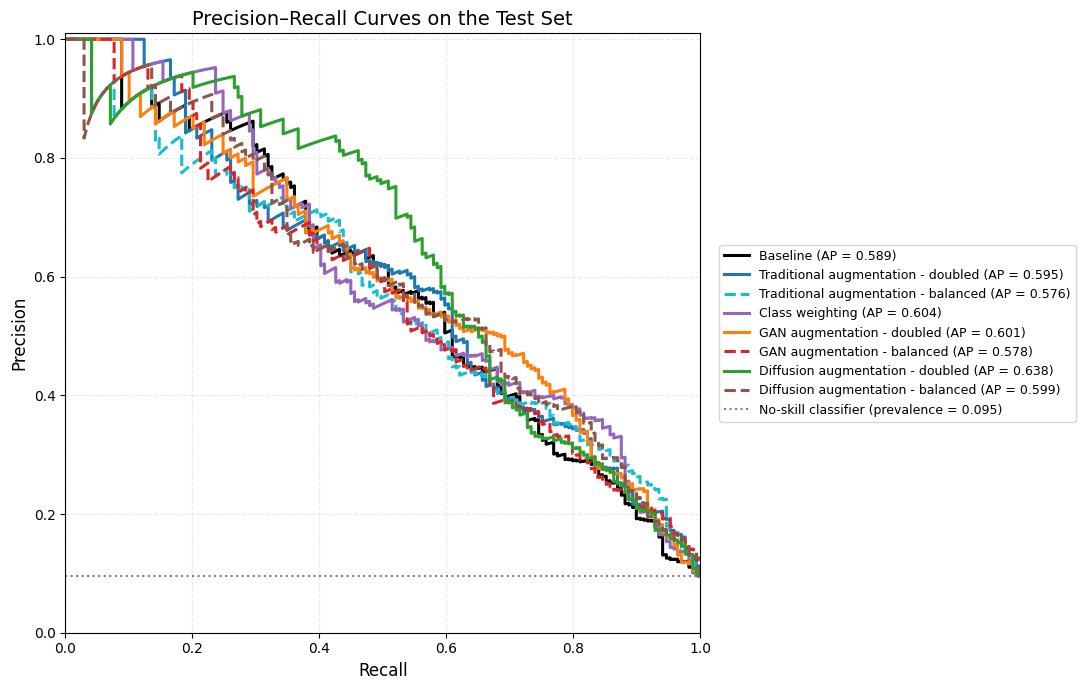

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/precision_recall_curves_all_experiments.png
/content/drive/MyDrive/bachelor_thesis_data/results/figures/precision_recall_curves_all_experiments.pdf


In [7]:
positive_prevalence = reference_labels.mean()

plt.figure(figsize=(11, 7))

for experiment_name, prediction_data in predictions.items():

    plt.plot(
        prediction_data["recall"],
        prediction_data["precision"],
        color=COLORS[experiment_name],
        linestyle=LINE_STYLES[experiment_name],
        linewidth=2.2,
        label=(
            f"{experiment_name} "
            f"(AP = {prediction_data['average_precision']:.3f})"
        )
    )

plt.axhline(
    y=positive_prevalence,
    color="#7F7F7F",
    linestyle=":",
    linewidth=1.5,
    label=(
        f"No-skill classifier "
        f"(prevalence = {positive_prevalence:.3f})"
    )
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Precision-Recall Curves on the Test Set",
    fontsize=14
)

plt.xlim(0, 1)
plt.ylim(0, 1.01)

plt.grid(
    alpha=0.25,
    linestyle="--"
)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()

pr_png_path = (
    FIGURE_DIR /
    "precision_recall_curves_all_experiments.png"
)

pr_pdf_path = (
    FIGURE_DIR /
    "precision_recall_curves_all_experiments.pdf"
)

plt.savefig(
    pr_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pr_pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(pr_png_path)
print(pr_pdf_path)